In [10]:
import matplotlib.pyplot as plt
import numpy as np

In [11]:
import pandas as pd 
url = r"C:\Users\Ready2Use\Desktop\my-folder\Ironhack-week4\first_project\notebooks\ocean_health_index.csv"
df_hhi2 = pd.read_csv(url)

In [12]:
df_hhi2

,REF_AREA,REF_AREA_LABEL,2012,2013,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
0,ABW,Aruba,70.79,70.10,70.09,70.52,71.28,72.14,77.65,80.87,79.94,79.39,76.43,64.90,67.50
1,AGO,Angola,63.33,64.57,64.57,67.00,67.66,66.70,65.71,61.90,59.76,59.23,59.41,57.91,57.89
2,AIA,Anguilla,72.17,70.60,70.82,70.86,70.74,70.21,70.36,70.30,70.36,70.35,70.44,70.63,70.87
3,ALB,Albania,62.95,63.27,63.86,66.55,66.16,66.70,67.38,67.52,71.79,71.70,71.19,65.38,69.68
4,ANT,Netherlands Antilles,74.66,74.98,74.97,74.92,77.45,77.45,77.44,77.44,76.61,76.51,76.33,76.35,76.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
189,WLD,World,71.46,72.24,72.88,73.36,73.48,73.54,73.66,73.80,73.87,73.69,73.92,69.03,68.78
190,WLF,Wallis-et-Futuna (Fr.),73.67,74.65,74.60,74.47,74.30,74.12,73.95,73.81,78.04,77.56,77.44,77.44,77.27
191,WSM,Samoa,71.95,72.24,72.37,72.60,71.57,71.65,72.04,72.46,74.99,74.99,74.99,66.15,64.71
192,YEM,"Yemen, Rep.",70.69,73.13,72.60,72.85,73.58,73.20,67.12,66.64,66.01,66.11,67.01,65.00,64.79


In [13]:
def clean_hhi2(df_hhi2):
    #make all column names lower case
    df_hhi2.columns = df_hhi2.columns.str.lower()
    #drop columns
    df_hhi2 = df_hhi2.drop(['ref_area', '2012', '2013'], axis=1)
    #filter GBR countries
    filtered_ref_area_label = df_hhi2.loc[df_hhi2['ref_area_label'].isin(['Australia', 'Papua New Guinea'])]
    df_hhi2_gbr = filtered_ref_area_label
    return df_hhi2_gbr

df_hhi2_gbr = clean_hhi2(df_hhi2)

In [14]:
display(df_hhi2_gbr)

,ref_area_label,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024
10,Australia,75.46,75.34,74.96,74.99,74.51,74.96,75.13,74.95,74.99,75.05,75.03
140,Papua New Guinea,75.26,76.89,77.47,77.30,77.18,76.42,73.39,72.60,73.41,67.11,66.21


In [15]:
df_hhi2_gbr.info()


<class 'pandas.DataFrame'>
RangeIndex: 2 entries, 10 to 140
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   ref_area_label  2 non-null      str    
 1   2014            2 non-null      float64
 2   2015            2 non-null      float64
 3   2016            2 non-null      float64
 4   2017            2 non-null      float64
 5   2018            2 non-null      float64
 6   2019            2 non-null      float64
 7   2020            2 non-null      float64
 8   2021            2 non-null      float64
 9   2022            2 non-null      float64
 10  2023            2 non-null      float64
 11  2024            2 non-null      float64
dtypes: float64(11), str(1)
memory usage: 324.0 bytes


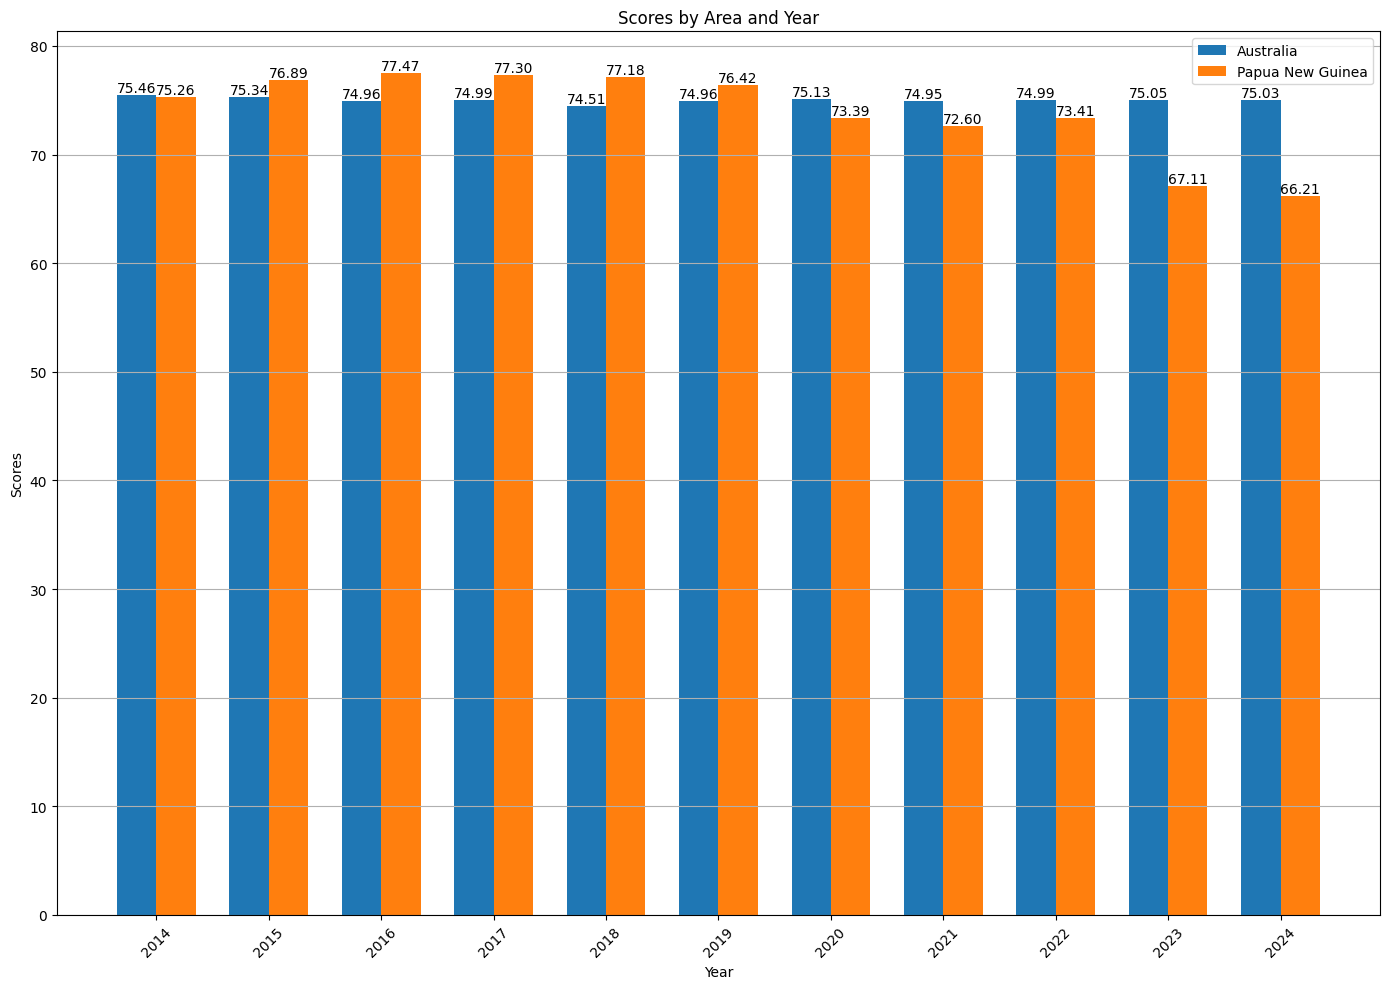

In [20]:
areas = df_hhi2_gbr['ref_area_label'].unique()  # 'Australia', 'Papua New Guinea'
categories = df_hhi2_gbr.columns[1:].tolist()  # Years from 2014 to 2024

# Prepare the data
# This assumes each 'ref_area_label' has exactly one entry per year
values_australia = df_hhi2_gbr[df_hhi2_gbr['ref_area_label'] == 'Australia'].iloc[0, 1:].values.astype(float)
values_papua = df_hhi2_gbr[df_hhi2_gbr['ref_area_label'] == 'Papua New Guinea'].iloc[0, 1:].values.astype(float)

# Setting positions and width for the bars
x = np.arange(len(categories))
width = 0.35

# Create the plot
fig, ax = plt.subplots(figsize=(14, 10))

# Plot each set of bars for different areas
bar1 = ax.bar(x - width/2, values_australia, width, label='Australia')
bar2 = ax.bar(x + width/2, values_papua, width, label='Papua New Guinea')

# Add some text for labels, title, and custom x-axis tick labels, etc.
ax.set_xlabel('Year')
ax.set_ylabel('Scores')
ax.set_title('Scores by Area and Year')
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.legend()

# Add data labels on top of each bar
for bar in bar1:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{bar.get_height():.2f}', ha='center', va='bottom')
for bar in bar2:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height(), 
            f'{bar.get_height():.2f}', ha='center', va='bottom')


# Add a grid for better readability
ax.yaxis.grid(True)

# Rotate x labels if necessary
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

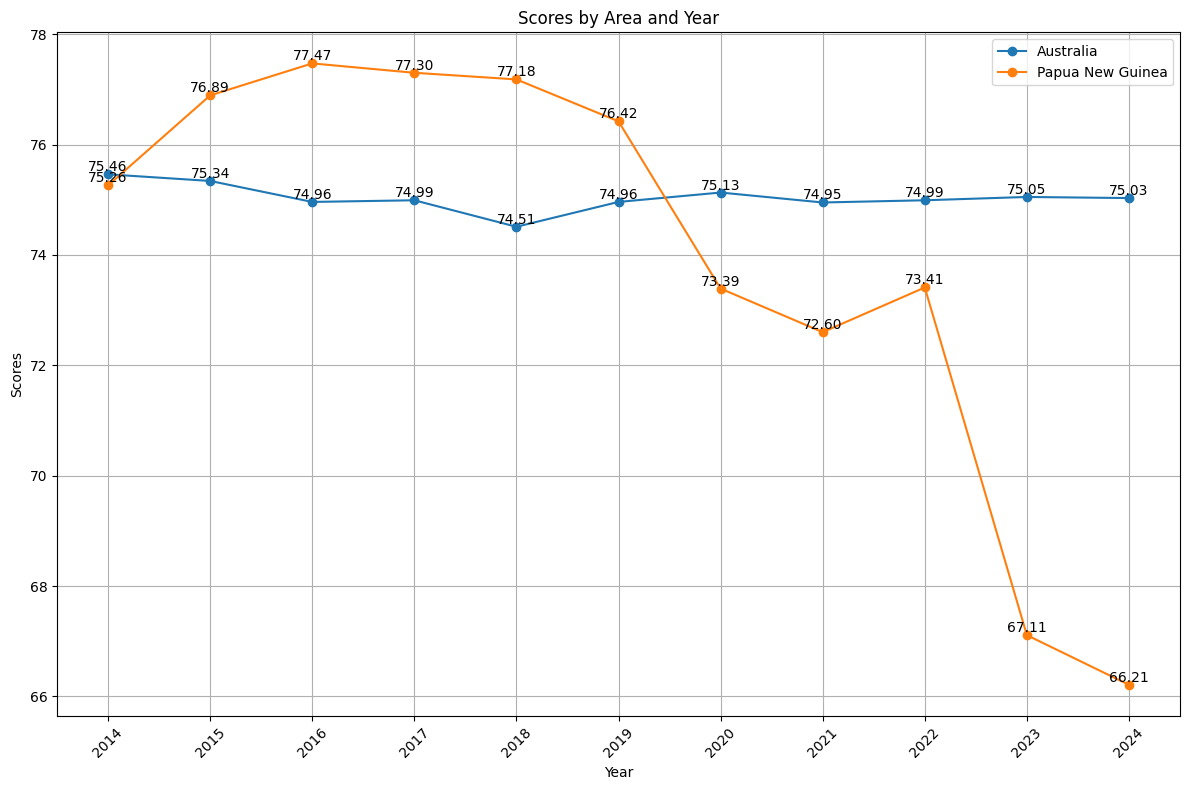

In [24]:
def plot_line_chart(df, title='Scores by Area and Year'):
    # Extract unique areas and years (assuming consistent DataFrame structure)
    areas = df['ref_area_label'].unique()
    categories = df.columns[1:].tolist()  # Years from 2014 to 2024

    # Create a plot
    fig, ax = plt.subplots(figsize=(12, 8))

    # Plot each area
    for area in areas:
        # Extract values for the current area
        values = df[df['ref_area_label'] == area].iloc[0, 1:].values.astype(float)
        x = np.arange(len(categories))
        
        # Plot the line
        ax.plot(x, values, marker='o', label=area)
        
        # Annotate each point with its value
        for i, val in enumerate(values):
            ax.text(i, val, f'{val:.2f}', ha='center', va='bottom')

    # Label plot
    ax.set_xlabel('Year')
    ax.set_ylabel('Scores')
    ax.set_title(title)
    ax.set_xticks(x)
    ax.set_xticklabels(categories)
    ax.legend()
    ax.grid(True)

    # Adjust layout to fit
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# Call the function using df_hhi2_gbr
plot_line_chart(df_hhi2_gbr)